In [1]:
# ВИДЕО С ТРЕКИНГОМ: https://drive.google.com/drive/folders/1yvvEuJayiOexcXJcW24ARnSlMqKMMv_L?usp=sharing
# ГИТХАБ: github.com/ArtemiyMitsel/cv-lab3


!pip install --upgrade pip
!pip install torch torchvision
!pip install segmentation-models-pytorch
!pip install albumentations
!pip install opencv-python-headless

import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm
import glob


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 94.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
drive.mount('/content/drive')

!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("viacheslavshalamov/russian-road-signs-segmentation-dataset")

print("Path to dataset files:", path)

dataset_path = path

print(f"\nDataset loaded to: {dataset_path}")

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    if level < 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
        if len(files) > 3:
            print(f'{subindent}... more {len(files) - 3} files')

json_files = glob.glob(f'{dataset_path}/**/via_region_data.json', recursive=True)
print(f"\nJSON files: {json_files}")

Mounted at /content/drive
Using Colab cache for faster access to the 'russian-road-signs-segmentation-dataset' dataset.
Path to dataset files: /kaggle/input/russian-road-signs-segmentation-dataset

Dataset loaded to: /kaggle/input/russian-road-signs-segmentation-dataset
russian-road-signs-segmentation-dataset/
  sign_dataset/

JSON files: ['/kaggle/input/russian-road-signs-segmentation-dataset/sign_dataset/val/via_region_data.json', '/kaggle/input/russian-road-signs-segmentation-dataset/sign_dataset/train/via_region_data.json']


In [3]:
SIGN_CLASSES = {
    0: 'background',
    1: 'road_sign',
}

NUM_CLASSES = len(SIGN_CLASSES)

In [4]:
class RussianRoadSignsDataset(Dataset):
    def __init__(self, annotations, transform=None):
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def create_mask_from_regions(self, image_shape, regions):
        h, w = image_shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        for region in regions:
            shape_attrs = region.get('shape_attributes', {})
            region_attrs = region.get('region_attributes', {})

            class_id = 1 if region_attrs.get('name') == 'road sign' else 0

            shape_name = shape_attrs.get('name', '')

            if shape_name == 'polygon':
                all_x = shape_attrs.get('all_points_x', [])
                all_y = shape_attrs.get('all_points_y', [])

                if all_x and all_y and len(all_x) == len(all_y):
                    points = np.array(list(zip(all_x, all_y)), dtype=np.int32)
                    cv2.fillPoly(mask, [points], class_id)

            elif shape_name == 'ellipse':
                cx = int(shape_attrs.get('cx', 0))
                cy = int(shape_attrs.get('cy', 0))
                rx = int(shape_attrs.get('rx', 0))
                ry = int(shape_attrs.get('ry', 0))

                cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, class_id, -1)

            elif shape_name == 'rect':
                x = int(shape_attrs.get('x', 0))
                y = int(shape_attrs.get('y', 0))
                width = int(shape_attrs.get('width', 0))
                height = int(shape_attrs.get('height', 0))

                cv2.rectangle(mask, (x, y), (x + width, y + height), class_id, -1)

        return mask

    def __getitem__(self, idx):
        ann = self.annotations[idx]

        image = cv2.imread(ann['path'])
        if image is None:
            image = np.zeros((512, 512, 3), dtype=np.uint8)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.create_mask_from_regions(image.shape, ann['regions'])

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask.long()

In [5]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8,
)

model = model.to(device)
model.eval()

print(f"DeepLabV3+ (ResNet50) loaded on {device}")
print(f"  Encoder: ResNet50 (pretrained on ImageNet)")
print(f"  Classes: 8 (for road signs)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

DeepLabV3+ (ResNet50) loaded on cuda
  Encoder: ResNet50 (pretrained on ImageNet)
  Classes: 8 (for road signs)


In [7]:
def calculate_iou(pred, target, num_classes):
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())

    return ious

def calculate_metrics(pred, target, num_classes, thresholds=[0.5, 0.75, 0.9]):
    ious = calculate_iou(pred, target, num_classes)
    valid_ious = [iou for iou in ious if not np.isnan(iou)]

    if len(valid_ious) == 0:
        return 0, 0, 0, 0

    mean_iou = np.mean(valid_ious)

    precision_recalls = {}
    for thresh in thresholds:
        above_thresh = sum(1 for iou in valid_ious if iou >= thresh)
        precision_recalls[thresh] = above_thresh / len(valid_ious) if valid_ious else 0

    return mean_iou, precision_recalls[0.5], precision_recalls[0.75], precision_recalls[0.9]

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    all_ious = []
    all_pr_05 = []
    all_pr_075 = []
    all_pr_09 = []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            for pred, mask in zip(preds, masks):
                miou, pr05, pr075, pr09 = calculate_metrics(pred, mask, num_classes)
                all_ious.append(miou)
                all_pr_05.append(pr05)
                all_pr_075.append(pr075)
                all_pr_09.append(pr09)

    return (total_loss / len(dataloader),
            np.mean(all_ious),
            np.mean(all_pr_05),
            np.mean(all_pr_075),
            np.mean(all_pr_09))

Parsing train annotations from via_region_data.json...
Train: 2054 images
Parsing val annotations from via_region_data.json...
Val: 127 images

DataLoaders ready
  Train batches: 257
  Val batches: 16


Validation: 100%|██████████| 16/16 [00:06<00:00,  2.49it/s]


Epoch 1/30
Train Loss: 0.5263, Val Loss: 0.1251
mIoU: 0.5317, IoU>=0.5: 0.5118, IoU>=0.75: 0.5000, IoU>=0.9: 0.5000


Validation: 100%|██████████| 16/16 [00:05<00:00,  2.90it/s]


Epoch 2/30
Train Loss: 0.0723, Val Loss: 0.0524
mIoU: 0.6304, IoU>=0.5: 0.6299, IoU>=0.75: 0.5157, IoU>=0.9: 0.5000


...

Epoch 28/30
Train Loss: 0.0046, Val Loss: 0.0179
mIoU: 0.8512, IoU>=0.5: 0.9449, IoU>=0.75: 0.7677, IoU>=0.9: 0.5472


Validation: 100%|██████████| 16/16 [00:05<00:00,  2.92it/s]


Epoch 29/30
Train Loss: 0.0045, Val Loss: 0.0178
mIoU: 0.8457, IoU>=0.5: 0.9488, IoU>=0.75: 0.7323, IoU>=0.9: 0.5236


Validation: 100%|██████████| 16/16 [00:05<00:00,  2.93it/s]


Epoch 30/30
Train Loss: 0.0046, Val Loss: 0.0185
mIoU: 0.8538, IoU>=0.5: 0.9409, IoU>=0.75: 0.7559, IoU>=0.9: 0.5433


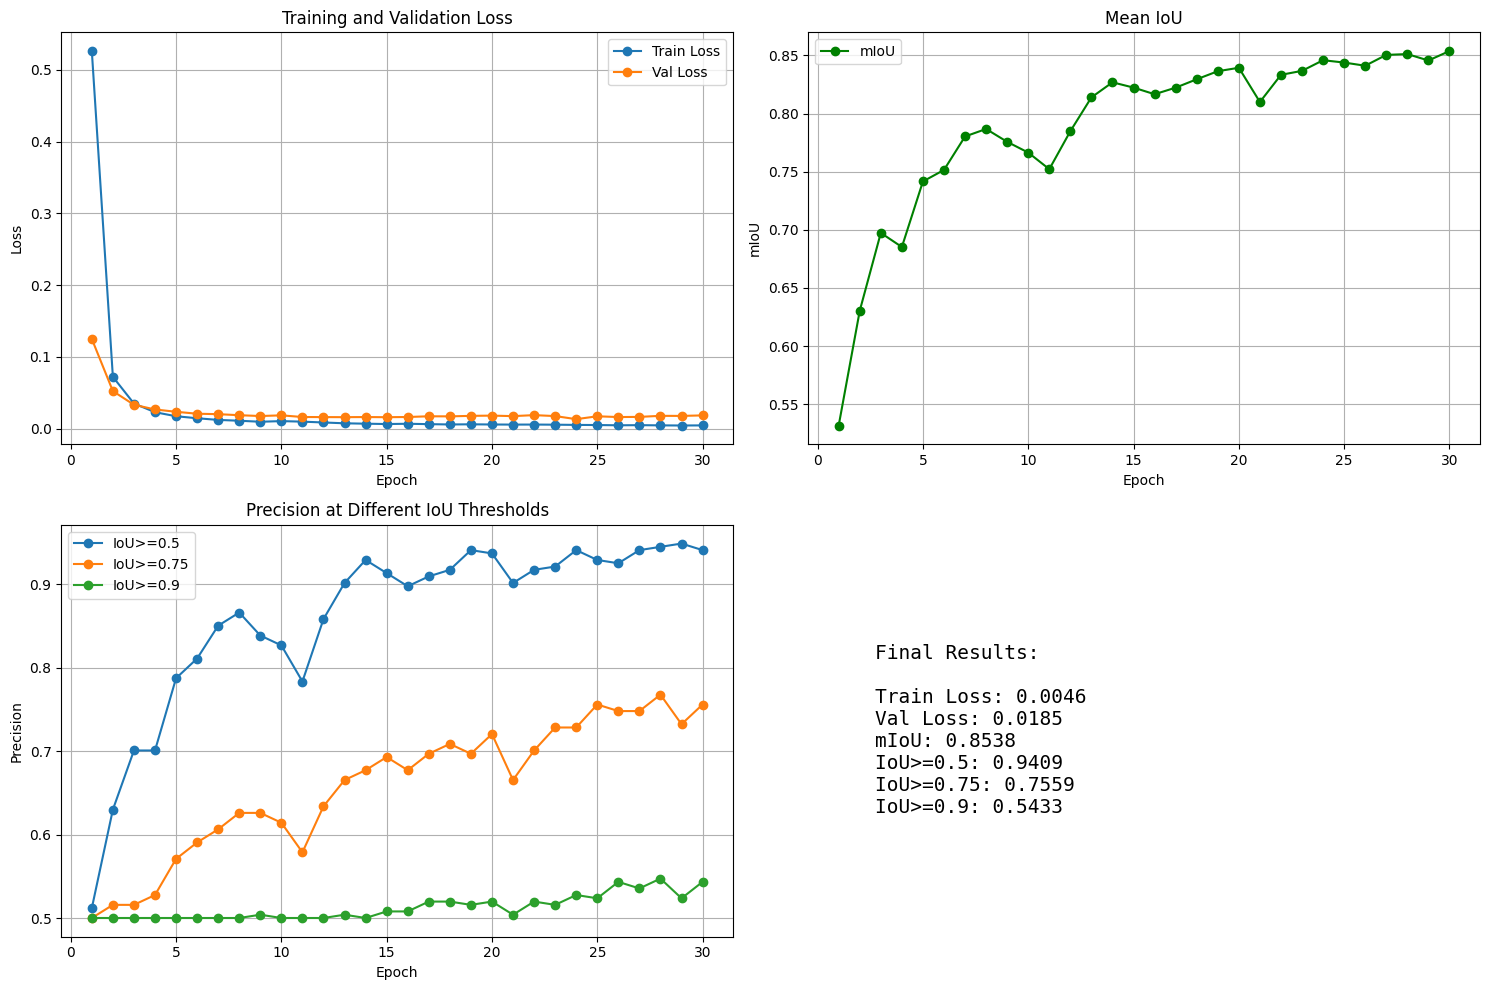


Training metrics plot saved to Google Drive


In [9]:
import os
import json
import numpy as np
import cv2
from pycocotools import mask as mask_utils


def parse_via_json(json_path, image_dir):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    annotations = []

    for img_key, img_data in data.items():
        if not isinstance(img_data, dict):
            continue

        filename = img_data.get('filename', '')
        if not filename:
            continue

        img_path = os.path.join(image_dir, filename)
        if not os.path.exists(img_path):
            continue

        regions_dict = img_data.get('regions', {})

        if not regions_dict:
            continue

        regions_list = []
        for region_id, region_data in regions_dict.items():
            if isinstance(region_data, dict):
                regions_list.append(region_data)

        if regions_list:
            annotations.append({
                'filename': filename,
                'path': img_path,
                'regions': regions_list
            })

    return annotations

train_json = os.path.join(dataset_path, 'sign_dataset/train/via_region_data.json')
val_json = os.path.join(dataset_path, 'sign_dataset/val/via_region_data.json')

train_image_dir = os.path.join(dataset_path, 'sign_dataset/train')
val_image_dir = os.path.join(dataset_path, 'sign_dataset/val')

print("Parsing train annotations from via_region_data.json...")
train_ann = parse_via_json(train_json, train_image_dir)
print(f"Train: {len(train_ann)} images")

print("Parsing val annotations from via_region_data.json...")
val_ann = parse_via_json(val_json, val_image_dir)
print(f"Val: {len(val_ann)} images")

train_dataset = RussianRoadSignsDataset(train_ann, transform=train_transform)
val_dataset = RussianRoadSignsDataset(val_ann, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"\nDataLoaders ready")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30

train_losses = []
val_losses = []
mious = []
pr05s = []
pr075s = []
pr09s = []


for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, miou, pr05, pr075, pr09 = validate(model, val_loader, criterion, device, NUM_CLASSES)


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    mious.append(miou)
    pr05s.append(pr05)
    pr075s.append(pr075)
    pr09s.append(pr09)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    print(f'mIoU: {miou:.4f}, IoU>=0.5: {pr05:.4f}, IoU>=0.75: {pr075:.4f}, IoU>=0.9: {pr09:.4f}')

torch.save(model.state_dict(), 'road_signs_segmentation.pth')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
axes[0, 0].plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='o')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(range(1, num_epochs+1), mious, label='mIoU', marker='o', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('mIoU')
axes[0, 1].set_title('Mean IoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(range(1, num_epochs+1), pr05s, label='IoU>=0.5', marker='o')
axes[1, 0].plot(range(1, num_epochs+1), pr075s, label='IoU>=0.75', marker='o')
axes[1, 0].plot(range(1, num_epochs+1), pr09s, label='IoU>=0.9', marker='o')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision at Different IoU Thresholds')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].axis('off')
summary_text = f'Final Results:\n\n'
summary_text += f'Train Loss: {train_losses[-1]:.4f}\n'
summary_text += f'Val Loss: {val_losses[-1]:.4f}\n'
summary_text += f'mIoU: {mious[-1]:.4f}\n'
summary_text += f'IoU>=0.5: {pr05s[-1]:.4f}\n'
summary_text += f'IoU>=0.75: {pr075s[-1]:.4f}\n'
summary_text += f'IoU>=0.9: {pr09s[-1]:.4f}'
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=14, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining metrics plot saved to Google Drive")



Example 1:


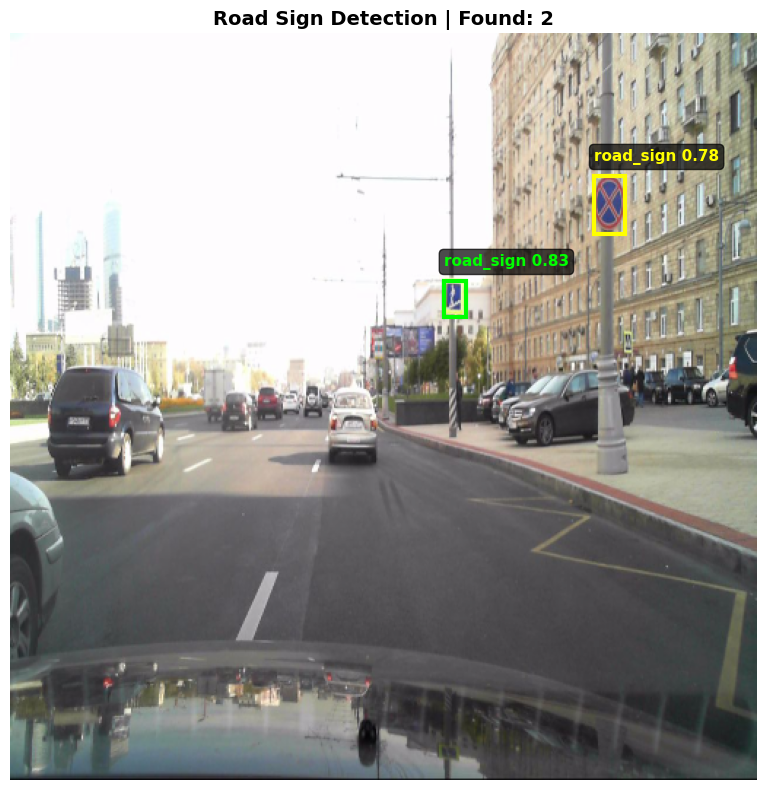


Example 2:


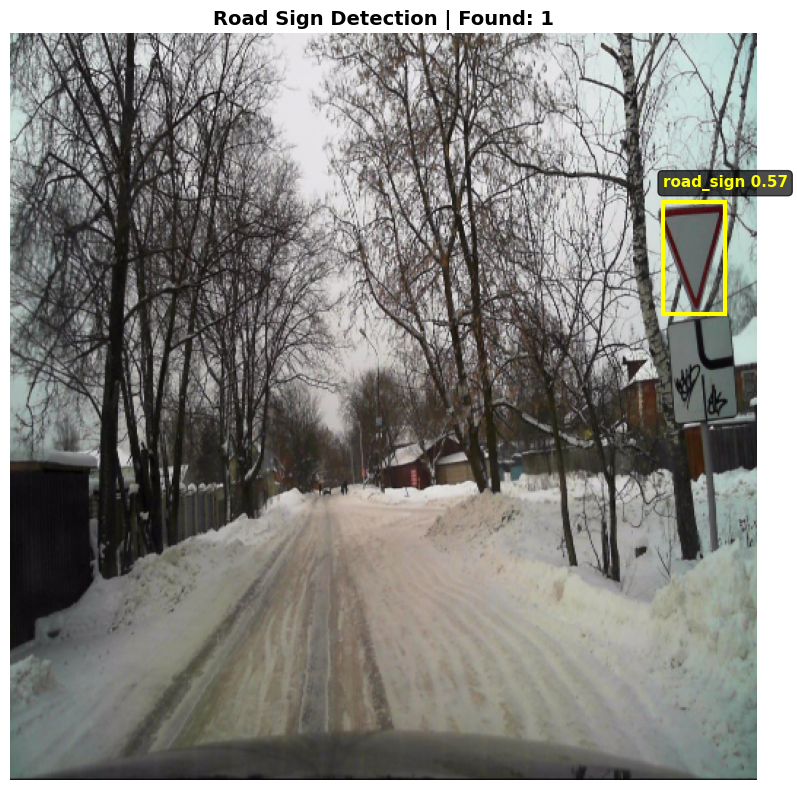


Example 3:


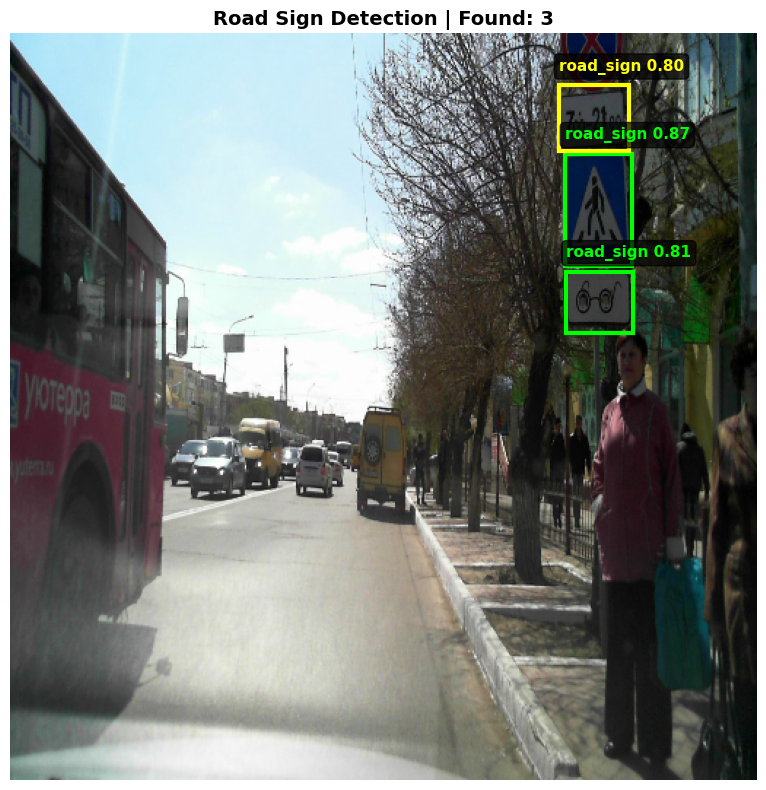

In [10]:
import random
from matplotlib import patches

def show_prediction_with_confidence(model, dataset, device, sample_idx=None):
    if sample_idx is None:
        sample_idx = random.randint(0, len(dataset)-1)

    model.eval()

    with torch.no_grad():
        image, gt_mask = dataset[sample_idx]


        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)


        image_batch = image.unsqueeze(0).to(device)
        output = model(image_batch)


        probs = torch.softmax(output, dim=1).squeeze(0)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        probs_np = probs.cpu().numpy()


        plt.figure(figsize=(12, 8))
        plt.imshow(img_display)


        unique_classes = np.unique(pred_mask)
        detection_count = 0

        for cls in unique_classes:
            if cls == 0:
                continue

            mask_cls = (pred_mask == cls).astype(np.uint8)
            contours, _ = cv2.findContours(mask_cls, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                area = cv2.contourArea(contour)
                if area > 100:
                    x, y, w, h = cv2.boundingRect(contour)


                    roi_probs = probs_np[cls, y:y+h, x:x+w]
                    confidence = roi_probs.mean()


                    if confidence > 0.8:
                        color = 'lime'
                    elif confidence > 0.5:
                        color = 'yellow'
                    else:
                        color = 'orange'

                    rect = patches.Rectangle((x, y), w, h, linewidth=3,
                                            edgecolor=color, facecolor='none')
                    plt.gca().add_patch(rect)

                    class_name = SIGN_CLASSES.get(cls, f'Class {cls}')
                    label = f'{class_name} {confidence:.2f}'

                    plt.text(x, y-10, label, color=color, fontsize=11,
                           weight='bold',
                           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

                    detection_count += 1

        plt.title(f'Road Sign Detection | Found: {detection_count}', fontsize=14, weight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

for i in range(3):
    print(f"\nExample {i+1}:")
    show_prediction_with_confidence(model, val_dataset, device)

In [13]:
from pathlib import Path

video_path = Path("/content/drive/MyDrive/lab3_vids")
output_video_path = Path("/content/drive/MyDrive/lab3_out_vids")

os.makedirs(output_video_path, exist_ok=True)


def process_video(video_path, model, device, output_path):
    cap = cv2.VideoCapture(str(video_path))

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    model.eval()
    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    frame_count = 0

    with torch.no_grad():
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            transformed = transform(image=frame_rgb)
            image_tensor = transformed['image'].unsqueeze(0).to(device)

            output = model(image_tensor)

            probs = torch.softmax(output, dim=1).squeeze(0)
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            pred_mask_resized = cv2.resize(pred_mask.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST)

            probs_resized = torch.nn.functional.interpolate(
                probs.unsqueeze(0),
                size=(height, width),
                mode='bilinear',
                align_corners=False
            ).squeeze(0).cpu().numpy()

            frame_with_boxes = frame.copy()
            unique_classes = np.unique(pred_mask_resized)

            for cls_id in unique_classes:
                if cls_id == 0:
                    continue

                mask_cls = (pred_mask_resized == cls_id).astype(np.uint8)
                contours, _ = cv2.findContours(mask_cls, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                for contour in contours:
                    area = cv2.contourArea(contour)
                    if area > 100:
                        x, y, w, h = cv2.boundingRect(contour)

                        roi_probs = probs_resized[cls_id, y:y+h, x:x+w]
                        confidence = roi_probs.mean()

                        if confidence > 0.8:
                            color = (0, 255, 0)
                        elif confidence > 0.5:
                            color = (0, 255, 255)
                        else:
                            color = (0, 165, 255)

                        cv2.rectangle(frame_with_boxes, (x, y), (x+w, y+h), color, 2)

                        class_name = SIGN_CLASSES.get(cls_id, f'Class {cls_id}')
                        label = f'{class_name} {confidence:.2f}'

                        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                        cv2.rectangle(frame_with_boxes, (x, y-text_h-10), (x+text_w, y), color, -1)

                        cv2.putText(frame_with_boxes, label, (x, y-5),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

            out.write(frame_with_boxes)

            frame_count += 1
            if frame_count % 100 == 0:
                print(frame_count)

    cap.release()
    out.release()

    return frame_count

video_files = [f for f in os.listdir(video_path) if f.endswith(('.mp4', '.avi', '.mov', '.MOV'))]

for video_file in video_files:
    input_path = os.path.join(video_path, video_file)
    output_path = output_video_path / f'box_output_{video_file}'

    print(f'Processing {video_file}...')
    frames = process_video(input_path, model, device, output_path)
    print(f'Processed {frames} frames. Output saved to {output_path}')

Processing IMG_3682.MOV...
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
Processed 1366 frames. Output saved to /content/drive/MyDrive/lab3_out_vids/box_output_IMG_3682.MOV
Processing IMG_3683.MOV...
100
200
300
400
500
600
700
800
900
1000
1100
1200
Processed 1293 frames. Output saved to /content/drive/MyDrive/lab3_out_vids/box_output_IMG_3683.MOV
Processing IMG_3684.MOV...
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
Processed 1665 frames. Output saved to /content/drive/MyDrive/lab3_out_vids/box_output_IMG_3684.MOV
Processing IMG_3685.MOV...
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
Processed 1577 frames. Output saved to /content/drive/MyDrive/lab3_out_vids/box_output_IMG_3685.MOV
Processing IMG_3686.MOV...
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
Processed 2712 frames. Output saved to /content/drive/MyDrive/lab3_out_vids/box_output_IMG_3686

In [14]:
from pathlib import Path

video_path = Path("/content/drive/MyDrive/lab3_vids")
output_video_path = Path("/content/drive/MyDrive/lab3_out_vids")

os.makedirs(output_video_path, exist_ok=True)


def process_video_with_confidence(video_path, model, device, output_path):
    cap = cv2.VideoCapture(str(video_path))

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    model.eval()
    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    frame_count = 0
    total_detections = 0
    id_switches = 0
    prev_detections = []

    with torch.no_grad():
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            transformed = transform(image=frame_rgb)
            image_tensor = transformed['image'].unsqueeze(0).to(device)

            output = model(image_tensor)
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            pred_mask_resized = cv2.resize(pred_mask.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST)

            colored_mask = np.zeros((height, width, 3), dtype=np.uint8)
            colors = [
                [0, 0, 0], [0, 0, 255]
            ]

            for cls_id in range(NUM_CLASSES):
                colored_mask[pred_mask_resized == cls_id] = colors[cls_id]

            overlay = cv2.addWeighted(frame, 0.5, colored_mask, 0.5, 0)

            detections_in_frame = 0
            unique_classes = np.unique(pred_mask_resized)

            current_boxes = []
            for cls_id in unique_classes:
                if cls_id == 0:
                    continue
                mask_cls = (pred_mask_resized == cls_id).astype(np.uint8)
                contours_temp, _ = cv2.findContours(mask_cls, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                for contour in contours_temp:
                    if cv2.contourArea(contour) > 200:
                        x, y, w, h = cv2.boundingRect(contour)
                        current_boxes.append((x, y, x+w, y+h))
                        detections_in_frame += 1

            if len(prev_detections) > 0 and len(current_boxes) > 0:
                matched = set()
                for curr_box in current_boxes:
                    best_iou = 0
                    best_match = None
                    for prev_idx, prev_box in enumerate(prev_detections):
                        if prev_idx in matched:
                            continue
                        x1 = max(curr_box[0], prev_box[0])
                        y1 = max(curr_box[1], prev_box[1])
                        x2 = min(curr_box[2], prev_box[2])
                        y2 = min(curr_box[3], prev_box[3])
                        if x2 > x1 and y2 > y1:
                            intersection = (x2 - x1) * (y2 - y1)
                            area1 = (curr_box[2] - curr_box[0]) * (curr_box[3] - curr_box[1])
                            area2 = (prev_box[2] - prev_box[0]) * (prev_box[3] - prev_box[1])
                            union = area1 + area2 - intersection
                            iou = intersection / union if union > 0 else 0
                            if iou > best_iou:
                                best_iou = iou
                                best_match = prev_idx
                    if best_iou < 0.3:
                        id_switches += 1
                    elif best_match is not None:
                        matched.add(best_match)

            prev_detections = current_boxes.copy()

            info_text = f'Frame: {frame_count} | Detections: {detections_in_frame} | ID Switches: {id_switches}'
            cv2.putText(overlay, info_text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

            out.write(overlay)

            frame_count += 1
            total_detections += detections_in_frame

            if frame_count % 100 == 0:
                print(f'  Frame {frame_count}, detections: {detections_in_frame}')

    cap.release()
    out.release()

    return frame_count, total_detections, id_switches


video_files = [f for f in os.listdir(video_path) if f.endswith(('.mp4', '.avi', '.mov', '.MOV'))]

print(f"Found video files: {len(video_files)}\n")

results = {}

for video_file in video_files:
    input_path = os.path.join(video_path, video_file)
    output_path = output_video_path / f'mask_output_{video_file}'

    print(f'{'='*60}')
    print(f'Processing: {video_file}')
    print(f'{'='*60}')

    frames, detections, switches = process_video_with_confidence(input_path, model, device, output_path)

    results[video_file] = {
        'frames': frames,
        'detections': detections,
        'id_switches': switches,
        'avg_detections': detections / frames if frames > 0 else 0
    }

    print(f'✓ Processed {frames} frames')
    print(f'✓ Total detections: {detections}')
    print(f'✓ ID Switches: {switches}')
    print(f'✓ Average detections per frame: {detections/frames:.2f}')
    print(f'✓ Saved to: {output_path}\n')

print(f"\n{'='*60}")
print("FINAL STATISTICS")
print(f"{'='*60}")
for video, stats in results.items():
    print(f"\n{video}:")
    print(f"  Frames: {stats['frames']}")
    print(f"  Detections: {stats['detections']}")
    print(f"  ID Switches: {stats['id_switches']}")
    print(f"  Average: {stats['avg_detections']:.2f} detections/frame")

Found video files: 5

Processing: IMG_3682.MOV
  Frame 100, detections: 0
  Frame 200, detections: 3
  Frame 300, detections: 3
  Frame 400, detections: 3
  Frame 500, detections: 3
  Frame 600, detections: 1
  Frame 700, detections: 0
  Frame 800, detections: 0
  Frame 900, detections: 0
  Frame 1000, detections: 0
  Frame 1100, detections: 0
  Frame 1200, detections: 0
  Frame 1300, detections: 1
✓ Processed 1366 frames
✓ Total detections: 1871
✓ ID Switches: 738
✓ Average detections per frame: 1.37
✓ Saved to: /content/drive/MyDrive/lab3_out_vids/mask_output_IMG_3682.MOV

Processing: IMG_3683.MOV
  Frame 100, detections: 3
  Frame 200, detections: 0
  Frame 300, detections: 1
  Frame 400, detections: 1
  Frame 500, detections: 2
  Frame 600, detections: 0
  Frame 700, detections: 0
  Frame 800, detections: 4
  Frame 900, detections: 0
  Frame 1000, detections: 0
  Frame 1100, detections: 1
  Frame 1200, detections: 2
✓ Processed 1293 frames
✓ Total detections: 1295
✓ ID Switches: 48